On extrait les VRP (Volatility Risk Premium) de NVDA

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.volatility_analyzer import VolatilityAnalyzer

# 1. Volatilité Réalisée (Passé avec fenêtre de 21 jours => 1 mois)
returns = pd.read_csv('../data/processed/chip_chain_returns.csv', index_col=0, parse_dates=True)
rv_series = VolatilityAnalyzer.calculate_realized_volatility(returns['NVDA'], window=21)
current_rv = rv_series.iloc[-1]

# 2. Volatilité Implicite (Futur pricé par le marché)
# On cherche l'IV ATM à 1 mois (~30 jours)
current_iv = VolatilityAnalyzer.extract_atm_iv('NVDA', target_days=30)

# 3. La Prime de Risque (VRP)
vrp = current_iv - current_rv

print(f"--- ANALYSE DE VOLATILITÉ : NVDA ---")
print(f"Volatilité Réalisée (30j passés) : {current_rv*100:.2f}%")
print(f"Volatilité Implicite (30j futurs) : {current_iv*100:.2f}%")
print(f"Volatility Risk Premium (VRP)     : {vrp*100:.2f}%")

if vrp > 0.05:
    print("\nSIGNAL : L'IV est très chère par rapport à l'historique récent.")
    print("STRATÉGIE : Vente de Volatilité (Short Straddle ATM)")
elif vrp < -0.02:
    print("\nSIGNAL : L'IV est sous-évaluée (Marché complaisant).")
    print("STRATÉGIE : Achat de Volatilité (Long Straddle ATM)")
else:
    print("\nSIGNAL : Marché efficient. Pas d'arbitrage évident.")

Nombres total de tickers :  18
Tickers :  ['USO', 'CGW', 'PICK', '^VIX', '^TNX', 'ASML', 'TSM', '0981.HK', 'NVDA', 'AMD', 'INTC', 'AVGO', 'AAPL', 'MSFT', 'GOOGL', 'TSLA', 'GLD', 'TLT']


[*********************100%***********************]  18 of 18 completed


Récupération de la chaîne d'options pour NVDA...
2939 contrats d'options liquides extraits avec succès.
--- ANALYSE DE VOLATILITÉ : NVDA ---
Volatilité Réalisée (30j passés) : 46.10%
Volatilité Implicite (30j futurs) : 37.24%
Volatility Risk Premium (VRP)     : -8.86%

SIGNAL : L'IV est sous-évaluée (Marché complaisant).
STRATÉGIE : Achat de Volatilité (Long Straddle ATM)


Coût de la mise en place du Straddle : 8.50 $


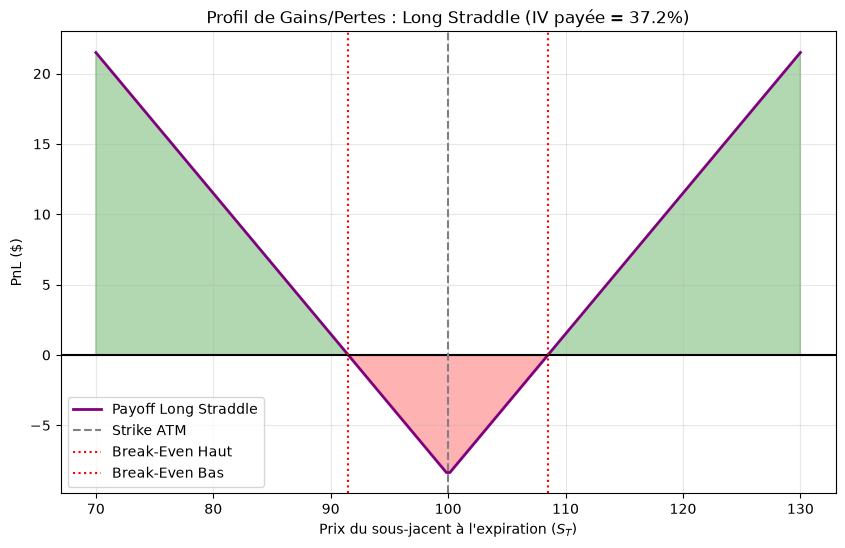

In [2]:
from src.options_pricer import BlackScholesPricer

# Paramètres du trade
S0 = 100.0  # Prix fictif pour la lisibilité
K = 100.0   # Straddle At-The-Money
T = 30 / 365.0
r = 0.045
sigma_trade = current_iv # On paie le prix de l'IV actuelle du marché

# On price les deux jambes du Straddle
pricer = BlackScholesPricer(S0, K, T, r, sigma_trade)
call_price = pricer.call_price()
put_price = pricer.put_price()
straddle_cost = call_price + put_price

print(f"Coût de la mise en place du Straddle : {straddle_cost:.2f} $")

# Génération du profil de Payoff à l'expiration (T=0)
ST_values = np.linspace(70, 130, 200)

# Payoff = Valeur intrinsèque à l'expiration - Coût initial
payoff_call = np.maximum(ST_values - K, 0) - call_price
payoff_put = np.maximum(K - ST_values, 0) - put_price
payoff_straddle = payoff_call + payoff_put

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(ST_values, payoff_straddle, color='purple', linewidth=2, label="Payoff Long Straddle")
plt.axhline(0, color='black', linestyle='-')
plt.axvline(K, color='gray', linestyle='--', label="Strike ATM")

# Points morts (Break-even points)
plt.axvline(K + straddle_cost, color='red', linestyle=':', label="Break-Even Haut")
plt.axvline(K - straddle_cost, color='red', linestyle=':', label="Break-Even Bas")

plt.fill_between(ST_values, payoff_straddle, 0, where=(payoff_straddle >= 0), color='green', alpha=0.3)
plt.fill_between(ST_values, payoff_straddle, 0, where=(payoff_straddle < 0), color='red', alpha=0.3)

plt.title(f"Profil de Gains/Pertes : Long Straddle (IV payée = {sigma_trade*100:.1f}%)")
plt.xlabel("Prix du sous-jacent à l'expiration ($S_T$)")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

On simule que notre outil de simulation (plus tard LSTM + HMM) a paniqué pour rien :
- IV à 40%
- RV à 20%

Ainsi le choix est de short un straddle

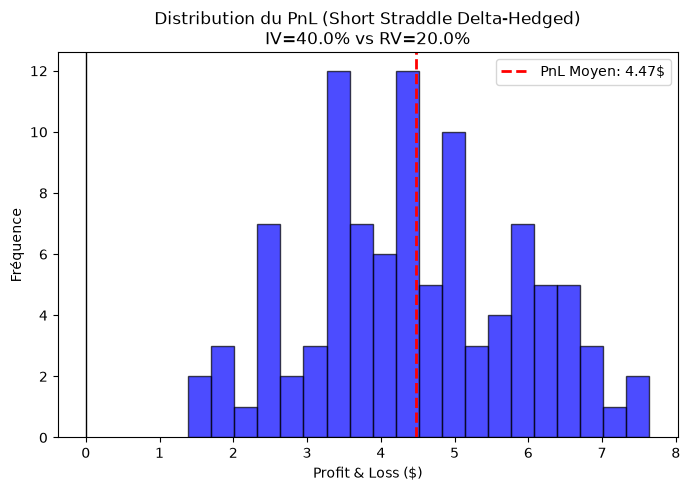

Probabilité de gain : 100.0%


In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from src.backtester import DeltaHedgingBacktester

# On va simuler 100 univers parallèles pour lisser la variance stochastique
M_simulations = 100
pnls = []

iv_market = 0.40  # Le marché a peur (IV très chère)
rv_actual = 0.20  # La réalité (Le LSTM avait raison, RV faible)

for i in range(M_simulations):
    backtester = DeltaHedgingBacktester(
        S0=100.0, K=100.0, T=30/365.0, r=0.045, 
        iv_market=iv_market, rv_actual=rv_actual, N_days=30,
        position='short'
    )
    result = backtester.run_simulation()
    pnls.append(result["Final_PnL"])

pnls = np.array(pnls)

plt.figure(figsize=(8, 5))
plt.hist(pnls, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(pnls), color='red', linestyle='dashed', linewidth=2, label=f"PnL Moyen: {np.mean(pnls):.2f}$")
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Distribution du PnL (Short Straddle Delta-Hedged)\nIV={iv_market*100}% vs RV={rv_actual*100}%")
plt.xlabel("Profit & Loss ($)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"Probabilité de gain : {np.mean(pnls > 0) * 100:.1f}%")

On regarde ce qui se passerait si on avait choisit de long un straddle dans le même cas

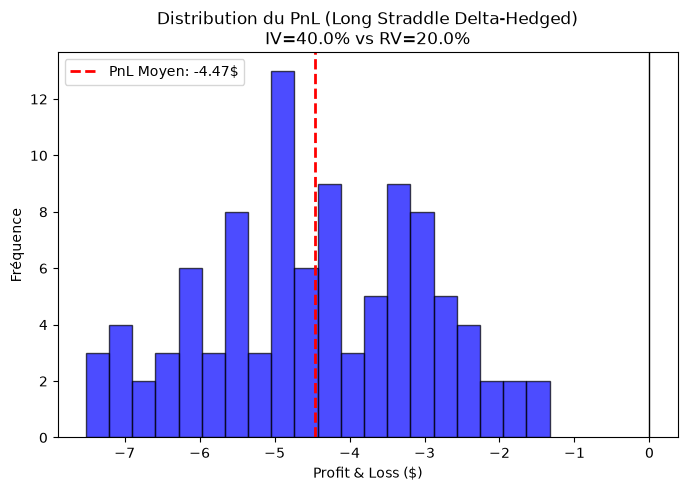

Probabilité de gain : 0.0%


In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from src.backtester import DeltaHedgingBacktester

# On va simuler 100 univers parallèles pour lisser la variance stochastique
M_simulations = 100
pnls = []

iv_market = 0.40  # Le marché a peur (IV très chère)
rv_actual = 0.20  # La réalité (Le LSTM avait raison, RV faible)

for i in range(M_simulations):
    backtester = DeltaHedgingBacktester(
        S0=100.0, K=100.0, T=30/365.0, r=0.045, 
        iv_market=iv_market, rv_actual=rv_actual, N_days=30,
        position='long'
    )
    result = backtester.run_simulation()
    pnls.append(result["Final_PnL"])

pnls = np.array(pnls)

plt.figure(figsize=(8, 5))
plt.hist(pnls, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(pnls), color='red', linestyle='dashed', linewidth=2, label=f"PnL Moyen: {np.mean(pnls):.2f}$")
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Distribution du PnL (Long Straddle Delta-Hedged)\nIV={iv_market*100}% vs RV={rv_actual*100}%")
plt.xlabel("Profit & Loss ($)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"Probabilité de gain : {np.mean(pnls > 0) * 100:.1f}%")

On regarde maintenant pour VRP = -0.20 (donc le mieux est Long Straddle)

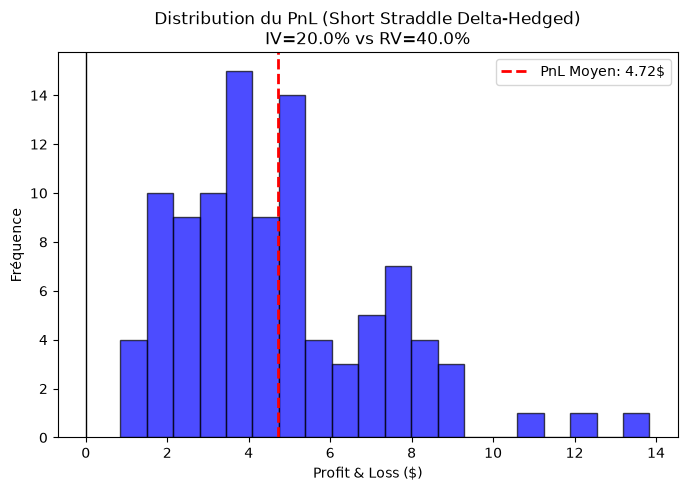

Probabilité de gain : 100.0%


In [5]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from src.backtester import DeltaHedgingBacktester

# On va simuler 100 univers parallèles pour lisser la variance stochastique
M_simulations = 100
pnls = []

iv_market = 0.20  # Le marché a peur (IV très chère)
rv_actual = 0.40  # La réalité (Le LSTM avait raison, RV faible)

for i in range(M_simulations):
    backtester = DeltaHedgingBacktester(
        S0=100.0, K=100.0, T=30/365.0, r=0.045, 
        iv_market=iv_market, rv_actual=rv_actual, N_days=30,
        position='long'
    )
    result = backtester.run_simulation()
    pnls.append(result["Final_PnL"])

pnls = np.array(pnls)

plt.figure(figsize=(8, 5))
plt.hist(pnls, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(pnls), color='red', linestyle='dashed', linewidth=2, label=f"PnL Moyen: {np.mean(pnls):.2f}$")
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Distribution du PnL (Short Straddle Delta-Hedged)\nIV={iv_market*100}% vs RV={rv_actual*100}%")
plt.xlabel("Profit & Loss ($)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"Probabilité de gain : {np.mean(pnls > 0) * 100:.1f}%")